### Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Load & Split

In [2]:
train_path = "Dry_Bean_Dataset/dry_bean_train.csv"
test_path = "Dry_Bean_Dataset/dry_bean_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

target = "class"
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print("Kích thước X_train: ", X_train.shape)
print("Kích thước X_test: ", X_test.shape)

Kích thước X_train:  (10834, 16)
Kích thước X_test:  (2709, 16)


### Scaling & Encoding

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

print("Các nhãn class: ", encoder.classes_)

Các nhãn class:  ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


### Training

In [4]:
log_model = LogisticRegression(max_iter=100, random_state=42)
log_model.fit(X_train_scaled, y_train_encoded)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_encoded)

print("Hoàn tất huấn luyện")

Hoàn tất huấn luyện


### Predict & Evaluate

In [5]:
y_pred_log = log_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

print("------------------------------Logistic Regression------------------------------")
print("Accuracy: ", accuracy_score(y_test_encoded, y_pred_log))
print(classification_report(y_test_encoded,y_pred_log, target_names=encoder.classes_))
print("-------------------------------------KNN---------------------------------------")
print("Accuracy: ", accuracy_score(y_test_encoded, y_pred_knn))
print(classification_report(y_test_encoded,y_pred_knn, target_names=encoder.classes_))

------------------------------Logistic Regression------------------------------
Accuracy:  0.9191583610188261
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709

-------------------------------------KNN---------------------------------------
Accuracy:  0.9154669619785899
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0

### Confusion Matrix

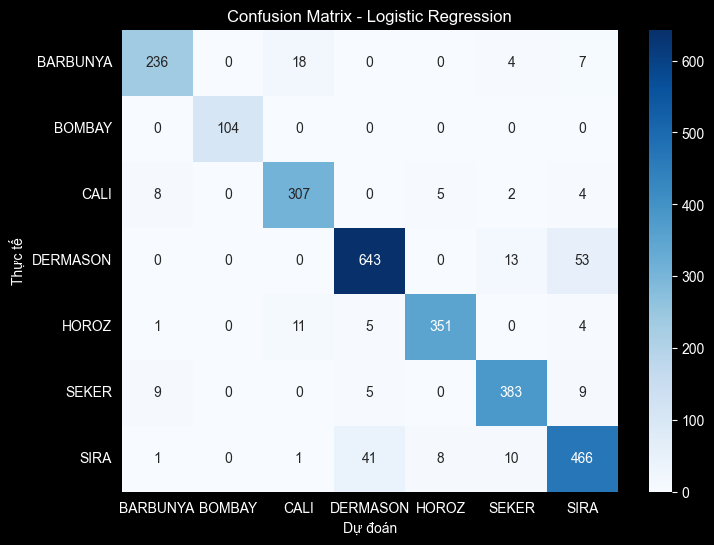

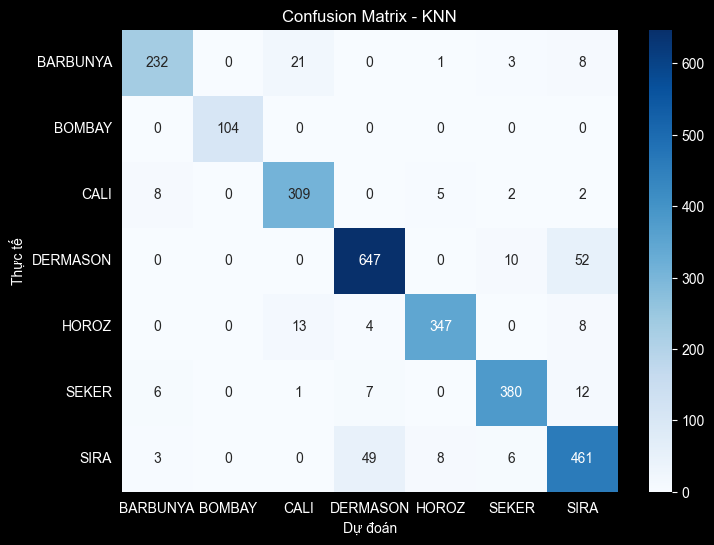

In [6]:
# Hàm vẽ Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()

# Trực quan hóa cho từng mô hình
plot_confusion_matrix(y_test_encoded, y_pred_log, "Logistic Regression")
plot_confusion_matrix(y_test_encoded, y_pred_knn, "KNN")

### Nhận xét
- **Logistic Regression** đạt độ chính xác (Accuracy) xấp xỉ 0.919 và F1-score trung bình là 0.92
- **KNN** đạt Accuracy xấp xỉ 0.915 và F1-score trung bình là 0.92
- **Kết luận:** Cả hai mô hình đều cho ra Accuracy và F1-score trung bình cao nên đều hiệu quả với Dry Bean Dataset này, tuy nhiên mô hình sử dụng Logistic Regression vẫn cho ra độ chính xác cao hơn một tí